# Análise Epidemiológica de Dengue dos anos de 2024 e 2025

_**Elaborado por:**_ `Vitor Emanuel Santos Cruz` (vitoremanuelsc089@gmail.com)

_**Data:**_ `Maio de 2026`

## **Introdução**
A dengue representa um dos principais desafios epidemiológicos enfrentados pelo sistema público de saúde brasileiro, especialmente em períodos de maior incidência sazonal. O aumento no número de notificações em diferentes regiões do país reforça a importância do monitoramento epidemiológico e da análise de dados públicos para compreender padrões de disseminação da doença.

Neste projeto, foi realizada uma análise exploratória de dados (EDA) utilizando registros oficiais do Sistema de Informação de Agravos de Notificação (SINAN), acessados por meio da biblioteca PySUS. O estudo utiliza dados referentes aos anos de 2024 e 2025, inicialmente considerando registros do estado de Minas Gerais e, posteriormente, aplicando um recorte específico para o município de Montes Claros.

A proposta do notebook não é produzir previsões epidemiológicas, mas sim investigar padrões presentes nos dados, compreender características das notificações e explorar possíveis comportamentos temporais e demográficos relacionados à dengue no município analisado.

## Objetivos da Análise
O presente estudo tem como objetivo aplicar técnicas de análise exploratória de dados em registros epidemiológicos da dengue, buscando organizar, tratar e interpretar informações provenientes do SINAN.
Além da exploração estatística e visual dos dados, o projeto também busca estruturar um pipeline analítico mais próximo de práticas profissionais de Data Science, incluindo etapas de coleta, tratamento, documentação e reprodutibilidade da análise.

## Perguntas Analíticas
Durante o desenvolvimento da análise, o projeto busca responder às seguintes questões:

1. Como os casos de dengue se distribuíram ao longo do período analisado em Montes Claros?

2. Existe diferença significativa entre os registros de notificações por sexo?

3. Quais faixas etárias concentraram maior número de notificações no município?

4. Qual foi a distribuição dos diagnósticos finais registrados nos dados analisados?

---
# Coleta de Dados

A coleta foi realizada utilizando a biblioteca PySUS em ambiente Linux (WSL), permitindo acesso automatizado aos registros de notificações de dengue referentes aos anos de 2024 e 2025 por meio do SINAN.

Após a coleta inicial dos registros do estado de Minas Gerais, os dados foram armazenados localmente em formato `.parquet`, visando melhorar a organização, desempenho e reprodutibilidade do pipeline analítico.

O formulário de notificação do SINAN possui um volume extenso de variáveis clínicas e laboratoriais. No entanto, para otimizar o processamento e focar diretamente nos objetivos desta Análise Exploratória (EDA), o pipeline de extração foi configurado para reter apenas as variáveis demográficas e epidemiológicas mais relevantes.

O processo automatizado de coleta encontra-se implementado no script `src/data_collection.py`. Os dados coletados foram armazenados inicialmente na pasta `data/raw`.

### Download da base de dados

```
    from pysus.online_data import SINAN
    SINAN.download('DENG', 2024)
    SINAN.download('DENG', 2025)
```

### Filtro inicial para o estado de Minas Gerais

```
    df_ano = pd.read_parquet(
        arquivo,
        columns=colunas,
        filters=[('SG_UF_NOT', '==', '31')]
    )
```

### Especificação de tabelas de interesse analítico

```
    colunas = ['TP_NOT', 'DT_NOTIFIC', 'DT_SIN_PRI', 'CS_SEXO', 'NU_IDADE_N', 'CLASSI_FIN', 'EVOLUCAO', 'SG_UF_NOT', 'ID_MUNICIP']
```

# Processamento e Limpeza de Dados

Após a etapa de coleta, os dados passaram por um processo de tratamento e padronização com o objetivo de melhorar a consistência das informações utilizadas na análise exploratória.

### Entre as principais etapas realizadas estão: 

- conversão de colunas temporais para formato de data, permitindo análises temporais mais consistentes.

```
    df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
    df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], errors='coerce')
```

- tratamento da variável de idade codificada do SINAN, já que a variável de idade (`NU_IDADE_N`) utiliza uma codificação específica do SINAN, em que o primeiro dígito representa a unidade temporal da idade (anos, meses ou dias). Foi criada uma função auxiliar para interpretar corretamente essa estrutura e converter os valores para anos.

```
    df['NU_IDADE_N'] = df['NU_IDADE_N'].apply(corrigir_idade)
```

- remoção de registros inconsistentes ou incompletos, onde idades superiores a 130 anos e registros com ausência de informações etárias.

```
    df = df.dropna(subset=['NU_IDADE_N'])
    df = df[df['NU_IDADE_N'] <= 130]
```

- filtragem geográfica para o município de Montes Claros por meio do código do IBGE, criando o recorte analítico principal do projeto.

```
    df_moc = df[df['ID_MUNICIP'] == '314330'].copy()
```

- padronização de categorias textuais, removendo inconsistências relacionadas a espaços e formatação dos registros.

```
    df_moc['CLASSI_FIN'] = df_moc['CLASSI_FIN'].astype(str).str.strip()
```

- mapeamento dos diagnósticos finais relacionados à dengue, utilizando um dicionário de categorias mais descritivas, facilitando a interpretação analítica dos dados.

```
    dicionario_dengue = {
        '10': 'Dengue Clássica', '10.0': 'Dengue Clássica',
        '11': 'Dengue com Alarme', '11.0': 'Dengue com Alarme',
        '12': 'Dengue Grave', '12.0': 'Dengue Grave',
        '5': 'Descartado', '5.0': 'Descartado',
        '8': 'Inconclusivo', '8.0': 'Inconclusivo'
    }
```

Após o processamento, os dados tratados foram armazenados na pasta `data/processed` em formato `.parquet`, permitindo maior organização e reprodutibilidade do pipeline analítico.

---
# Análise Exploratória dos Dados (EDA)

Após a conclusão do pipeline de extração e higienização dos dados, dispomos de um dataset consolidado, focado estritamente nas notificações de Dengue do município de Montes Claros/MG para os anos de 2024 e 2025.

A Análise Exploratória de Dados (EDA) nesta etapa tem como objetivo inspecionar as propriedades estruturais, distribuições e relações entre as variáveis selecionadas. Mais do que gerar visualizações isoladas, esta análise busca responder a três pilares fundamentais de interesse epidemiológico:

**Dinâmica Temporal (Sazonalidade):** Como os casos de dengue se distribuem ao longo dos meses? Existe um padrão claro de sazonalidade que coincide com os regimes climáticos da região?

**Perfil Demográfico dos Afetados:** Quais faixas etárias e sexos biológicos concentram o maior volume de notificações na cidade?

**Diagnóstico Final e Gravidade:** Qual é a distribuição dos diagnósticos finais registrados? Qual a proporção de notificações classificadas como dengue clássica, dengue com alarme, dengue grave, descartado ou inconclusivo?

# Visualização e Insights

## Preparação do Ambiente

In [1]:
#import de bibliotecas necessarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# definições e configuração visual padrão para os gráficos
# 1. Definindo o df principal (Minas Gerais)
caminho_moc = '../data/processed/dengue_moc_limpo.parquet'
caminho_minas = '../data/raw/dados_dengue_minas.parquet'

df = pd.read_parquet(caminho_minas)

# 2. Definindo o df_moc
df_moc = pd.read_parquet(caminho_moc)

# 3. Definindo especificos para 2024 e 2025
df_2024 = df_moc[df_moc['DT_SIN_PRI'].dt.year == 2024].copy()
df_2025 = df_moc[df_moc['DT_SIN_PRI'].dt.year == 2025].copy()

# 4. Padronização 
plt.rcParams['axes.titlesize'] = 16        
plt.rcParams['axes.titleweight'] = 'bold'  
plt.rcParams['axes.titlepad'] = 15         
plt.rcParams['axes.labelsize'] = 12        
plt.rcParams['figure.titlesize'] = 18 

COR_PADRAO = "#0072B2"
COR_SECUNDARIA = "#D55E00"
COR_NEUTRA = "#999999"

    

### Impacto do Processamento e Qualidade dos Dados

A aplicação dos filtros geográficos e as rotinas de limpeza reduziram a dimensionalidade do *dataset* bruto, focando estritamente no escopo da análise:
* **Redução de Registros:** Milhares de registros foram descartados ao filtrar exclusivamente o município de Montes Claros (IBGE: 314330). Além disso, linhas com ausência crítica de informações temporais (sem a data de primeiros sintomas) foram removidas, pois inviabilizariam a análise de sazonalidade.

In [3]:
print("Análise de Qualidade: Percentual de dados ausentes por coluna na base processada de Montes Claros:")

percentual_nulos = (df_moc.isnull().sum() / len(df_moc)) * 100
percentual_nulos = percentual_nulos[percentual_nulos > 0].round(2).sort_values(ascending=False)

for coluna, percentual in percentual_nulos.items():
    print(f"{coluna}: {percentual:.2f}%")
    
print(f"Registros na base bruta de Minas Gerais: {len(df):,}")
print(f"Registros na base processada de Montes Claros: {len(df_moc):,}")

percentual_moc = (len(df_moc) / len(df)) * 100
print(f"Percentual mantido após filtro para Montes Claros: {percentual_moc:.2f}%")

Análise de Qualidade: Percentual de dados ausentes por coluna na base processada de Montes Claros:
DIAGNOSTICO: 0.14%
Registros na base bruta de Minas Gerais: 3,641,334
Registros na base processada de Montes Claros: 35,854
Percentual mantido após filtro para Montes Claros: 0.98%


## Análise

### Sazonalidade

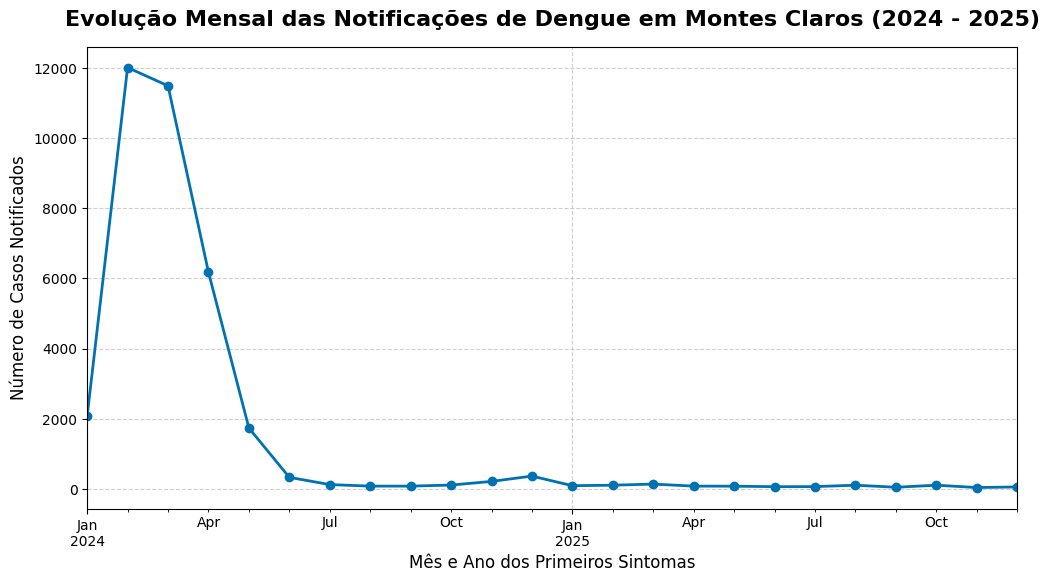

In [4]:
df_grafico = df_moc[(df_moc['DT_SIN_PRI'].dt.year >= 2024) & (df_moc['DT_SIN_PRI'].dt.year <= 2025)].copy()

df_grafico['ANO_MES'] = df_grafico['DT_SIN_PRI'].dt.to_period('M')

# ordenação
casos_por_mes = df_grafico['ANO_MES'].value_counts().sort_index()

plt.figure(figsize=(12, 6))

# bolinhas nos meses
casos_por_mes.plot(kind='line', marker='o', color=COR_PADRAO, linewidth=2)


plt.title('Evolução Mensal das Notificações de Dengue em Montes Claros (2024 - 2025)')
plt.xlabel('Mês e Ano dos Primeiros Sintomas', fontsize=12)
plt.ylabel('Número de Casos Notificados', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

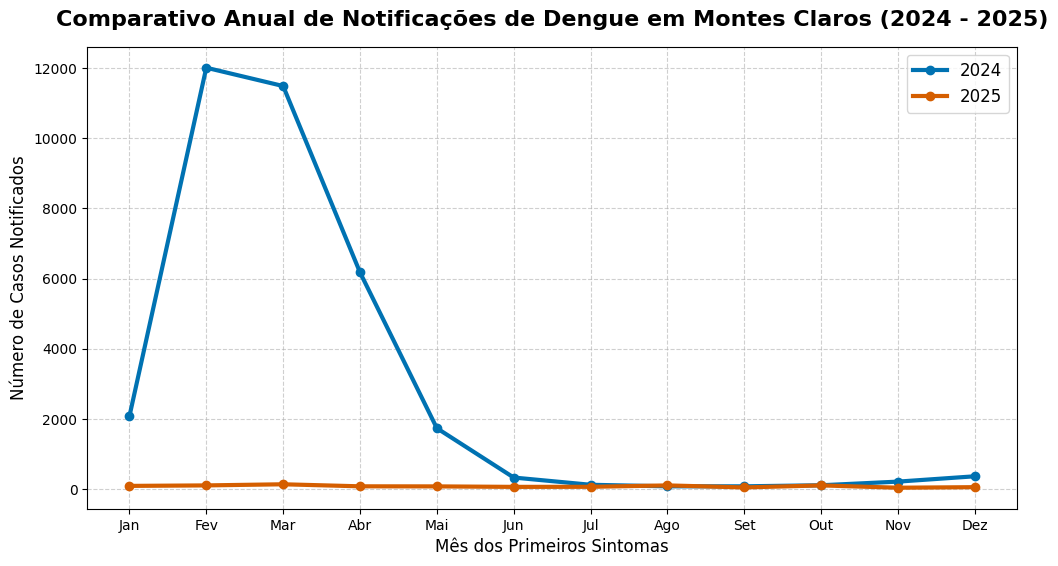

In [5]:
# conta os casos e agrupa
casos_2024 = df_2024['DT_SIN_PRI'].dt.month.value_counts().sort_index()
casos_2025 = df_2025['DT_SIN_PRI'].dt.month.value_counts().sort_index()

# tamanho do gráfico
plt.figure(figsize=(12, 6))

casos_2024.plot(kind='line', marker='o', color=COR_PADRAO, linewidth=3, label='2024')

casos_2025.plot(kind='line', marker='o', color=COR_SECUNDARIA, linewidth=3, label='2025')

plt.title('Comparativo Anual de Notificações de Dengue em Montes Claros (2024 - 2025)')
plt.xlabel('Mês dos Primeiros Sintomas', fontsize=12)
plt.ylabel('Número de Casos Notificados', fontsize=12)

# eixo de baixo
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# legenda
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Insight: Sazonalidade
**2024:**
- Os dados indicam maior concentração de notificações nos primeiros meses de 2024
- Redução expressiva ao longo do período analisado

**2025:**
- O volume de notificações aparece consideravelmente menor em relação a 2024. 

**Conclusão:** Os dados indicam maior concentração de notificações nos primeiros meses de 2024, comportamento compatível com padrões sazonais frequentemente observados em casos como esse. No entanto, a análise não incorpora variáveis climáticas, portanto não permite estabelecer relação causal com volume de chuvas. O cenário de 2025 apresenta volume menor de notificações em relação a 2024. No entanto, a análise não permite afirmar se essa redução está relacionada a ações de controle, fatores climáticos, mudanças na circulação viral ou outros fatores externos não incorporados ao estudo.

### Perfil Demográfico

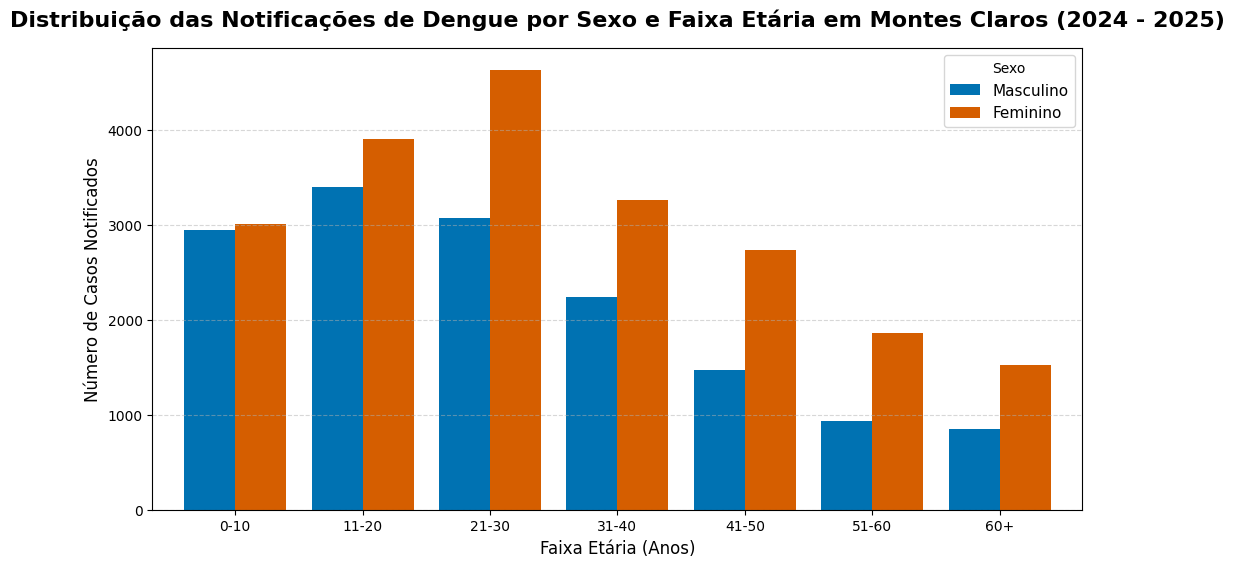

In [6]:
# cortes de dados
cortes = [-1, 10, 20, 30, 40, 50, 60, 150] # Começa no -1 para garantir que bebês de 0 anos entrem
nomes_faixas = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+']

# separar as idades
df_moc['FAIXA_ETARIA'] = pd.cut(df_moc['NU_IDADE_N'], bins=cortes, labels=nomes_faixas)

tabela_perfil = pd.crosstab(df_moc['FAIXA_ETARIA'], df_moc['CS_SEXO'])

# ignorar casos não preenchidos
colunas_sexo = [col for col in ['M', 'F'] if col in tabela_perfil.columns]
tabela_perfil = tabela_perfil[colunas_sexo]

tabela_perfil.plot(kind='bar', figsize=(12, 6), color=[COR_PADRAO, COR_SECUNDARIA], width=0.8)

plt.title('Distribuição das Notificações de Dengue por Sexo e Faixa Etária em Montes Claros (2024 - 2025)')
plt.xlabel('Faixa Etária (Anos)', fontsize=12)
plt.ylabel('Número de Casos Notificados', fontsize=12)

plt.legend(['Masculino', 'Feminino'], title='Sexo', fontsize=11)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

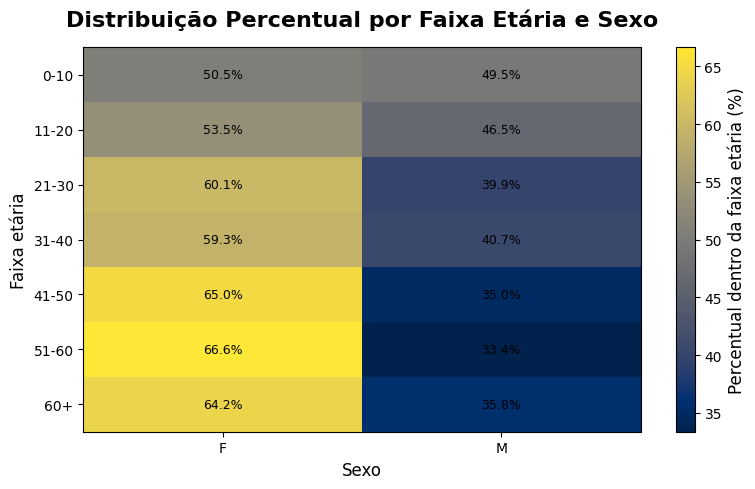

In [7]:
tabela_heatmap = pd.crosstab(df_moc['FAIXA_ETARIA'], df_moc['CS_SEXO'], normalize='index').mul(100)

plt.figure(figsize=(8, 5))

imagem = plt.imshow(
    tabela_heatmap,
    aspect='auto',
    cmap='cividis'
)

plt.title('Distribuição Percentual por Faixa Etária e Sexo')
plt.xlabel('Sexo')
plt.ylabel('Faixa etária')

plt.xticks(
    ticks=range(len(tabela_heatmap.columns)),
    labels=tabela_heatmap.columns
)

plt.yticks(
    ticks=range(len(tabela_heatmap.index)),
    labels=tabela_heatmap.index
)

for i in range(len(tabela_heatmap.index)):
    for j in range(len(tabela_heatmap.columns)):
        valor = tabela_heatmap.iloc[i, j]
        plt.text(j, i, f'{valor:.1f}%', ha='center', va='center', fontsize=9)

plt.colorbar(imagem, label='Percentual dentro da faixa etária (%)')
plt.tight_layout()
plt.show()

#### Insight: Perfil Demográfico
**Faixa Etária:**
- Concentração expressiva de notificações na população economicamente ativa (adultos entre 20 e 50 anos).
- Menor incidência em um dos extremos demográficos (idosos).
- Extremo de crianças e adolescente (0 a 20 anos) apesentam volume relevante.

**Sexo Biológico:**
- Volume de casos apresenta prevalência moderada no sexo feminino.

**Conclusão:** A distribuição das notificações indica maior concentração em faixas etárias adultas, especialmente entre 20 e 50 anos. Também se observa ligeiro predomínio de registros no sexo feminino em algumas faixas etárias. Entretanto, esses resultados devem ser interpretados apenas como distribuição dos registros notificados, sem inferir comportamentos individuais, exposição ao vetor ou padrões de cuidado em saúde.
Foi permitido observar a composição percentual das notificações por sexo dentro de cada faixa etária. Diferenças entre os grupos podem indicar variações na distribuição dos registros, mas não devem ser interpretadas diretamente como diferenças de exposição, risco ou comportamento individual sem a incorporação de outras variáveis explicativas.

Além da contagem absoluta de notificações, também foi analisada a distribuição percentual dos registros por sexo. Essa visualização permite comparar a participação relativa de cada grupo no total de notificações, reduzindo a dependência da escala absoluta dos dados.

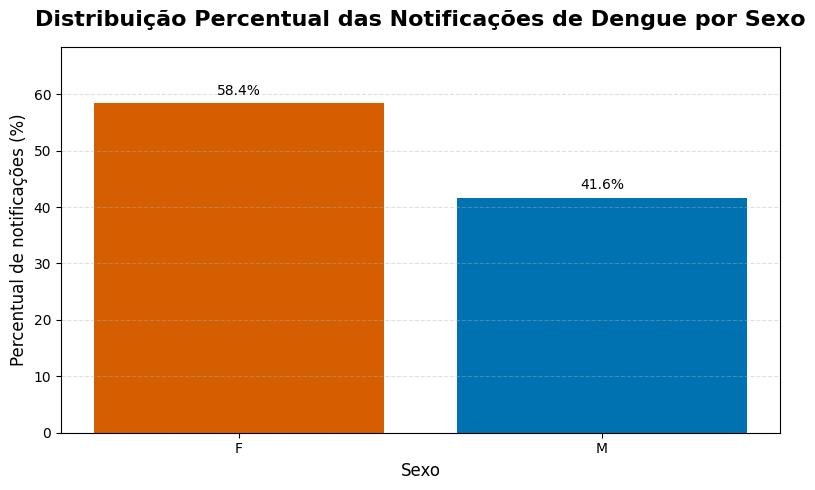

In [8]:
percentual_sexo = (
    df_moc['CS_SEXO']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

cores = [COR_SECUNDARIA, COR_PADRAO]

plt.figure(figsize=(8, 5))

barras = plt.bar(
    percentual_sexo.index,
    percentual_sexo.values,
    color=cores
)

plt.title('Distribuição Percentual das Notificações de Dengue por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Percentual de notificações (%)')
plt.ylim(0, percentual_sexo.max() + 10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura + 1, f'{altura:.1f}%', ha='center', va='bottom', fontsize=10 )

plt.tight_layout()
plt.show()

#### Insight: Distribuição Percentual
Indica a participação relativa de cada sexo no conjunto de notificações analisadas. Caso exista diferença entre os grupos, ela deve ser interpretada como uma diferença na composição dos registros notificados, e não como evidência direta de maior exposição, maior risco ou comportamento específico de busca por atendimento.

#### Intervalo entre Início dos Sintomas e Notificação
Nesta etapa, foi analisado o intervalo registrado entre a data dos primeiros sintomas (`DT_SIN_PRI`) e a data de notificação (`DT_NOTIFIC`). O objetivo é verificar se há diferenças relevantes nesse intervalo entre os sexos, comparando os registros de Montes Claros com o conjunto de Minas Gerais.

**É importante destacar que essa variável representa o intervalo registrado no sistema, não necessariamente o tempo exato de procura por atendimento médico.**

-> Média GERAL de Minas Gerais: 3.14 dias
-> Média das MULHERES (MG): 3.23 dias
-> Média dos HOMENS (MG): 3.03 dias



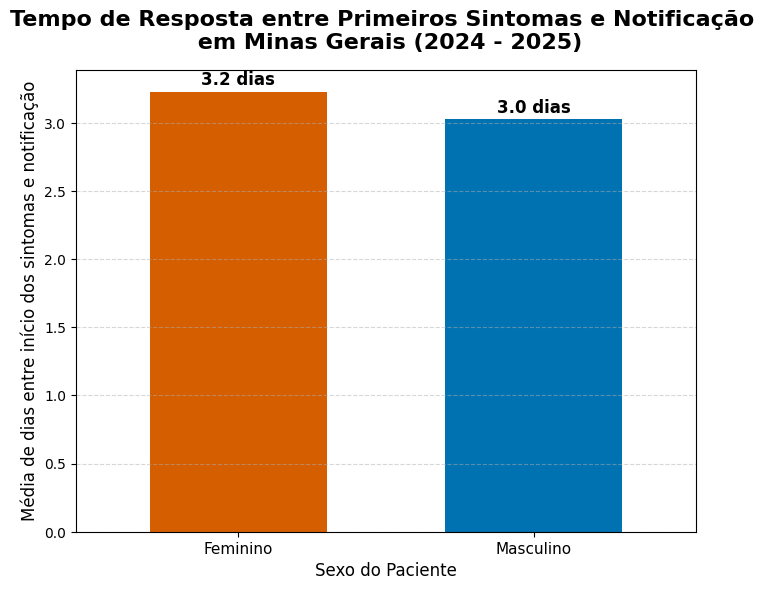

In [9]:
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], errors='coerce')

df['DIAS_ATRASO'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days

# Filtra intervalos válidos entre início dos sintomas e notificação
df_mg_comportamento = df[(df['DIAS_ATRASO'] >= 0) & (df['DIAS_ATRASO'] <= 30)].copy()

# Agrupa por sexo e tira a média de dias
media_atraso_mg = df_mg_comportamento.groupby('CS_SEXO')['DIAS_ATRASO'].mean()


print(f"-> Média GERAL de Minas Gerais: {df_mg_comportamento['DIAS_ATRASO'].mean():.2f} dias")
print(f"-> Média das MULHERES (MG): {media_atraso_mg['F']:.2f} dias")
print(f"-> Média dos HOMENS (MG): {media_atraso_mg['M']:.2f} dias\n")

plt.figure(figsize=(8, 6))

# Usando Verde e Amarelo Okabe-Ito para diferenciar de Montes Claros
cores_mg = [COR_SECUNDARIA, COR_PADRAO]

media_atraso_mg[['F', 'M']].plot(kind='bar', color=cores_mg, width=0.6)

plt.title('Tempo de Resposta entre Primeiros Sintomas e Notificação \n em Minas Gerais (2024 - 2025)')
plt.xlabel('Sexo do Paciente', fontsize=12)
plt.ylabel('Média de dias entre início dos sintomas e notificação', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Feminino', 'Masculino'], rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, valor in enumerate(media_atraso_mg[['F', 'M']]):
    plt.text(i, valor + 0.05, f"{valor:.1f} dias", ha='center', fontsize=12, fontweight='bold')

plt.show()

-> Média GERAL da cidade: 2.57 dias
-> Média das MULHERES: 2.63 dias
-> Média dos HOMENS: 2.48 dias



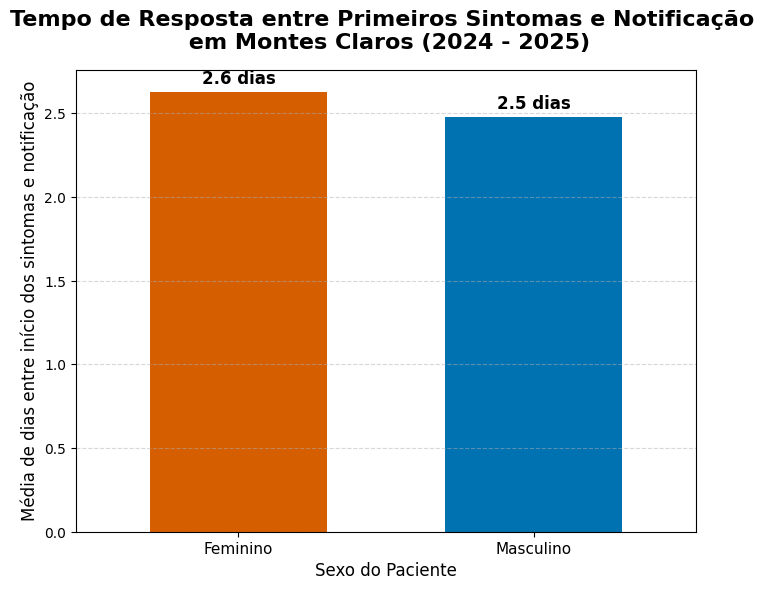

In [10]:
df_moc['DIAS_ATRASO'] = (df_moc['DT_NOTIFIC'] - df_moc['DT_SIN_PRI']).dt.days

# Remove intervalos negativos ou muito altos, possivelmente associados a inconsistências de registro
df_comportamento = df_moc[(df_moc['DIAS_ATRASO'] >= 0) & (df_moc['DIAS_ATRASO'] <= 30)].copy()

# agrupa por sexo e tira a média de dias
media_atraso = df_comportamento.groupby('CS_SEXO')['DIAS_ATRASO'].mean()

# descrição
print(f"-> Média GERAL da cidade: {df_comportamento['DIAS_ATRASO'].mean():.2f} dias")
print(f"-> Média das MULHERES: {media_atraso['F']:.2f} dias")
print(f"-> Média dos HOMENS: {media_atraso['M']:.2f} dias\n")

plt.figure(figsize=(8, 6))


cores = [COR_SECUNDARIA, COR_PADRAO]

media_atraso[['F', 'M']].plot(kind='bar', color=cores, width=0.6)

plt.title('Tempo de Resposta entre Primeiros Sintomas e Notificação \n em Montes Claros (2024 - 2025)')
plt.xlabel('Sexo do Paciente', fontsize=12)
plt.ylabel('Média de dias entre início dos sintomas e notificação', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Feminino', 'Masculino'], rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, valor in enumerate(media_atraso[['F', 'M']]):
    plt.text(i, valor + 0.05, f"{valor:.1f} dias", ha='center', fontsize=12, fontweight='bold')

plt.show()

#### Insight: Intervalo entre início dos sintomas e notificação por sexo
**Sexo:**
- Os dados sugerem pequena diferença no intervalo médio entre início dos sintomas e notificação entre os sexos. Entretanto, a diferença observada é baixa e não permite inferir comportamentos individuais de busca por atendimento.
Montes Claros: 0.15 dias de diferença (Feminino - Masculino)

Minas Gerais: 0.2 dias de diferença (Feminino - Masculino)

**Conclusão:** As médias observadas são muito próximas entre os sexos, tanto em Montes Claros quanto no conjunto de Minas Gerais. Dessa forma, os dados não indicam diferença relevante no intervalo registrado entre início dos sintomas e notificação. Ainda assim, essa variável não deve ser interpretada diretamente como tempo de procura por atendimento, pois depende também do fluxo de registro e notificação no sistema.

### Indicadores de Gravidade

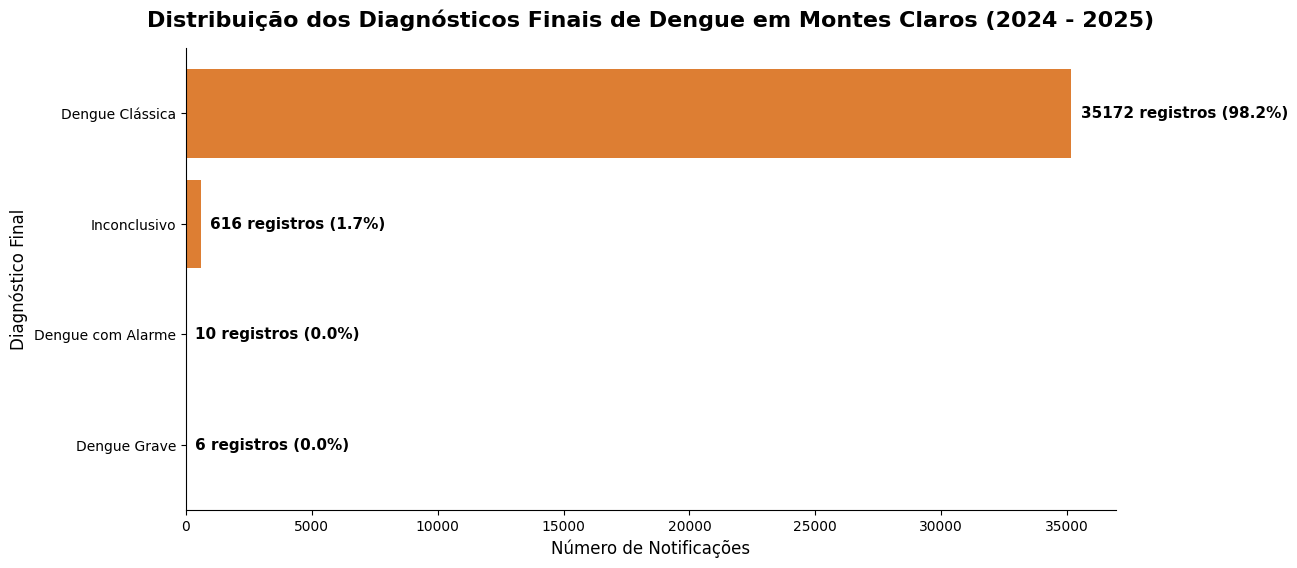

In [11]:
# conta e ordena do maior pro menor
contagem_diagnostico = df_moc['DIAGNOSTICO'].value_counts(dropna=True).sort_values(ascending=True)
total_casos = contagem_diagnostico.sum()

plt.figure(figsize=(12, 6))

# barras horizontais
barras = plt.barh(contagem_diagnostico.index, contagem_diagnostico.values, color='#D55E00', alpha=0.8)

plt.title('Distribuição dos Diagnósticos Finais de Dengue em Montes Claros (2024 - 2025)')
plt.xlabel('Número de Notificações', fontsize=12)
plt.ylabel('Diagnóstico Final', fontsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# escreve as descrições
for barra in barras:
    largura = barra.get_width() # valor absoluto
    porcentagem = (largura / total_casos) * 100

    # escreve o texto na frente da barra
    plt.text(largura + (total_casos * 0.01),
             barra.get_y() + barra.get_height()/2,
             f"{int(largura)} registros ({porcentagem:.1f}%)",
             va='center', fontsize=11, fontweight='bold')

plt.show()

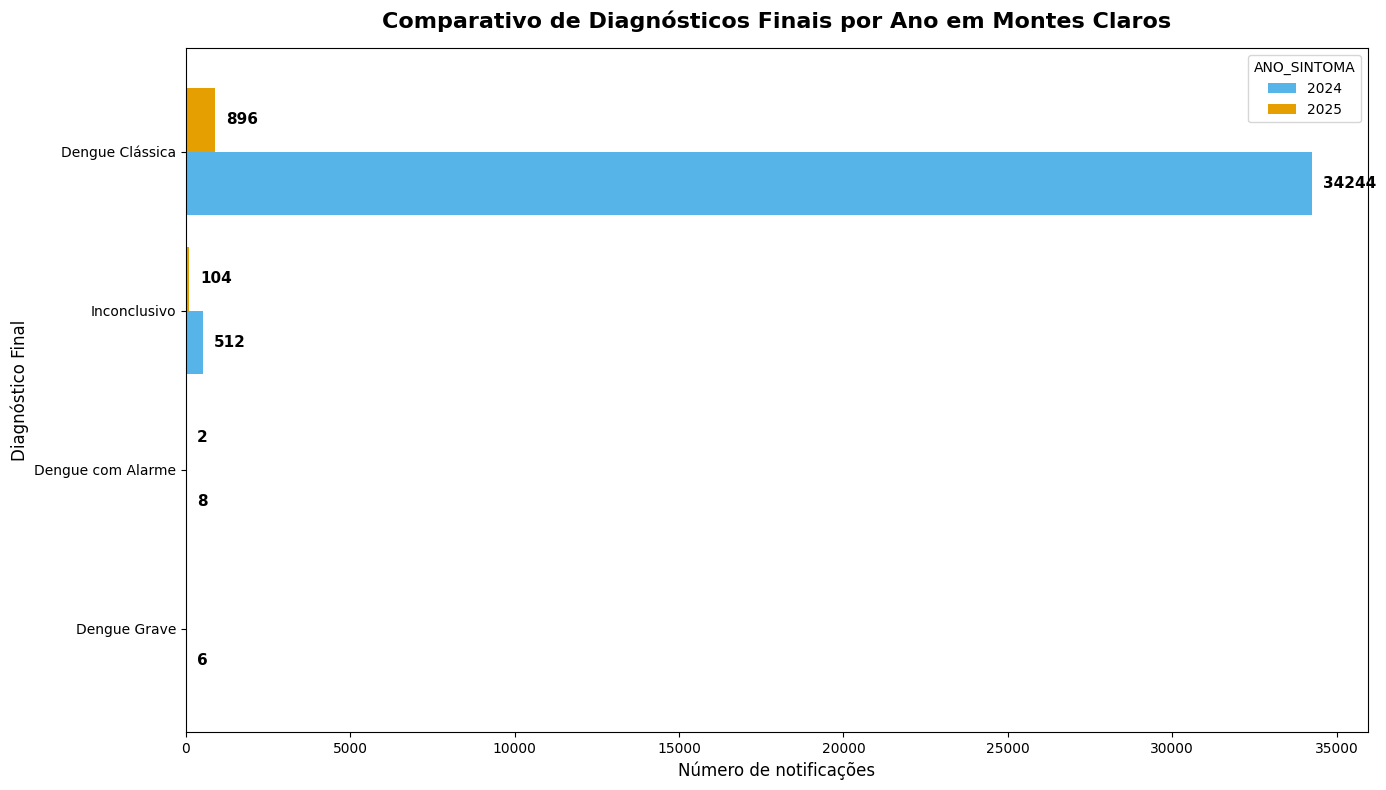

In [12]:
df_moc['ANO_SINTOMA'] = df_moc['DT_SIN_PRI'].dt.year

tabela_comparativa = pd.crosstab(df_moc['DIAGNOSTICO'], df_moc['ANO_SINTOMA'])

anos_analise = [ano for ano in [2024, 2025] if ano in tabela_comparativa.columns]
tabela_comparativa = tabela_comparativa[anos_analise]

tabela_comparativa['Total'] = tabela_comparativa.sum(axis=1)
tabela_comparativa = tabela_comparativa.sort_values('Total', ascending=True).drop(columns=['Total'])

# pinta o gráfico e monta ele
ax = tabela_comparativa.plot(kind='barh', figsize=(14, 8), color=['#56B4E9', '#E69F00'], width=0.8)

plt.title('Comparativo de Diagnósticos Finais por Ano em Montes Claros')
plt.xlabel('Número de notificações', fontsize=12)
plt.ylabel('Diagnóstico Final', fontsize=12)

for p in ax.patches:
    largura = p.get_width()
    if largura > 0:
        ax.text(largura + (tabela_comparativa.max().max() * 0.01), #  X
                p.get_y() + p.get_height() / 2,                  #  Y
                f"{int(largura)}",
                va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Além da contagem absoluta dos diagnósticos finais, também foi calculada a distribuição percentual das categorias. Essa visualização permite compreender a participação relativa de cada classificação no conjunto de registros analisados.

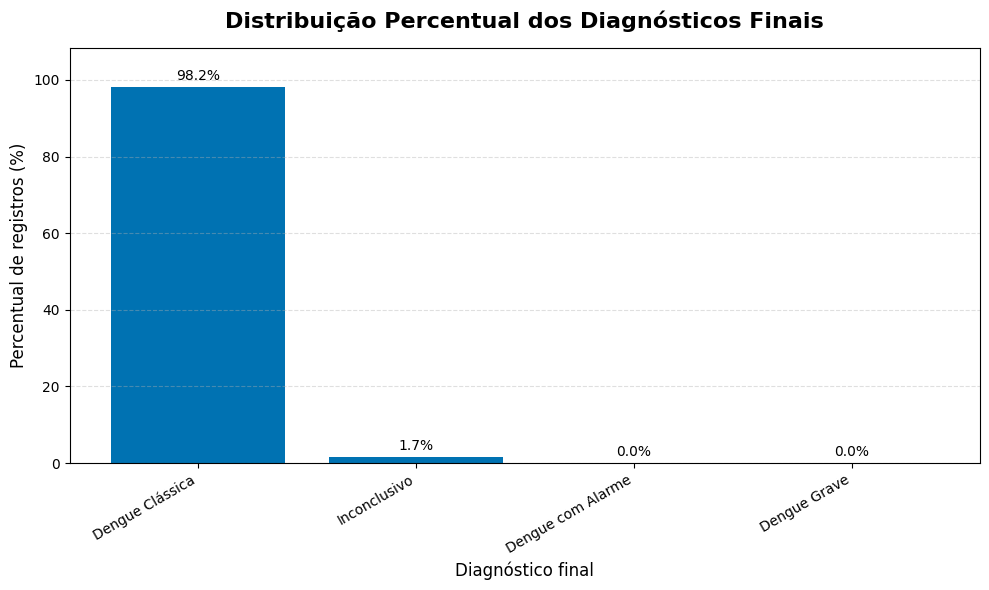

In [13]:
percentual_diagnostico = (
    df_moc['DIAGNOSTICO']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

barras = plt.bar(
    percentual_diagnostico.index,
    percentual_diagnostico.values,
    color=COR_PADRAO
)

plt.title('Distribuição Percentual dos Diagnósticos Finais')
plt.xlabel('Diagnóstico final')
plt.ylabel('Percentual de registros (%)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, percentual_diagnostico.max() + 10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 1,
        f'{altura:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### Insight: Evolução Clínica e Gravidade
**Dengue Clássica:**
- Representa a maior proporção dos diagnósticos em ambos os períodos analisados.

**Dengue com Alarme e Dengue Grave:**
- **2024:** Escalada preocupante nos números absolutos de casos graves.
- **2025:** Queda abrupta, com os casos críticos praticamente desaparecendo dos registros.

**Conclusão:** Os registros de 2024 apresenta maior volume absoluto de classificações associadas à dengue com alarme e dengue grave em comparação a 2025. No entanto, como a análise se baseia em notificações e classificações finais disponíveis, não é possível afirmar aumento de letalidade sem uma investigação específica dos desfechos e óbitos, somente supor por esses indicadores.
A distribuição percentual dos diagnósticos finais indica predominância de determinadas classificações nos registros analisados. Categorias associadas a maior gravidade aparecem em menor proporção, mas ainda assim são relevantes para a compreensão do perfil das notificações. Esses resultados devem ser interpretados considerando possíveis inconsistências, campos incompletos e diferenças entre notificação e confirmação.

# Limitações dos Dados

Os dados do SINAN representam notificações registradas no sistema, e não necessariamente a totalidade dos casos de dengue ocorridos no município. Dessa forma, os resultados podem estar sujeitos à subnotificação, atrasos de atualização e diferenças entre o momento de ocorrência dos sintomas, a notificação e a consolidação dos registros.

Necessidade de olhar crítico para campos incompletos, inconsistências de preenchimento e variações na qualidade dos registros. Algumas variáveis exigiram tratamento específico, como a idade codificada no padrão do SINAN e os códigos de classificação final da doença, o que tornou necessária a criação de regras de padronização e dicionários auxiliares para facilitar a interpretação dos dados.

Além disso, a análise não incorpora variáveis externas, como dados climáticos, indicadores socioeconômicos, informações sobre ações de controle vetorial ou capacidade da rede de saúde. Por isso, os padrões observados ao longo do tempo não devem ser interpretados como relações causais, mas como indícios exploratórios que podem orientar análises futuras mais aprofundadas.

Portanto, os resultados apresentados devem ser compreendidos como uma análise descritiva e exploratória dos registros disponíveis, útil para identificar padrões iniciais, mas insuficiente para estabelecer conclusões definitivas sobre causas, comportamentos populacionais ou dinâmica epidemiológica completa da dengue em Montes Claros.

# Conclusão

Os resultados indicam variações temporais nas notificações, com maior concentração de registros em determinados períodos do ano, comportamento compatível com padrões sazonais observados em doenças virais transmitidas por mosquitos. No entanto, como a análise não inclui variáveis climáticas ou ambientais, não é possível estabelecer relações causais para essas variações.

Também foram observadas diferenças na distribuição das notificações entre sexos e faixas etárias, bem como pequenas variações no intervalo entre início dos sintomas e notificação. Esses resultados devem ser interpretados de forma descritiva, sem inferir diretamente comportamentos individuais ou padrões de procura por atendimento.

A distribuição dos diagnósticos finais indicou predominância de registros classificados como dengue clássica, enquanto categorias de maior gravidade apareceram em menor proporção. Ainda assim, os resultados devem ser analisados considerando limitações dos dados de notificação, como subnotificação, campos incompletos, inconsistências e atrasos de atualização.

Portanto, o estudo oferece uma visão exploratória inicial sobre os registros de dengue em Montes Claros, contribuindo para a identificação de padrões temporais e demográficos.